# 14 — Equations and Inequalities Involving Absolute Value

**Equations and Inequalities ▸ 6.** The **absolute value** $|x|$ is one of the simplest and
most useful ideas in all of math: it is the **distance** of $x$ from $0$ on the number line.
Distance forgets direction — it only cares *how far*. So $|5|=5$ and $|-5|=5$: both are $5$
steps from the origin.

Mental picture: think of the number line as a road and $0$ as your home. $|x|$ is how far
$x$ is from home, ignoring whether you walked left or right. More generally, $|x-c|$ is the
distance between $x$ and $c$. With that one picture, every equation and inequality in this
topic becomes a sentence about distance:
- $|x-c| = r$ — "points exactly $r$ away from $c$" — **two** points, $c\pm r$.
- $|x-c| < r$ — "points **closer** than $r$ to $c$" — the **interval** $(c-r,\,c+r)$.
- $|x-c| > r$ — "points **farther** than $r$ from $c$" — **two rays** away from the middle.

**Why it matters for AI.** $|x|$ is the **1-D $L^1$ norm** — the way we measure size and
error. The **mean absolute error (MAE)** loss is an average of $|{\text{prediction}-\text{truth}}|$.
The set $|x-c|\le r$ is a 1-D **ball**; in higher dimensions the $L^1$ ball (a diamond) is
what makes **Lasso** regression push weights to exactly $0$ (sparsity). And $|x|$ has a sharp
corner at $0$ where it is not differentiable — the same corner as **ReLU** — which is why AI
uses *subgradients* there. So this humble V-shape is everywhere.

## Quick recall (spaced repetition)
From session 13 (Solving Inequalities). Solutions at the **end of §1**.

1. Solve $x^2 - x - 6 > 0$ with a sign chart. Give the answer in interval notation.
2. Solve $-2x + 1 \ge 7$. **(what special step is needed?)**
3. **(older, topic 8)** Simplify $\sqrt{(x-5)^2}$ for any real $x$.

## What we cover today
1. The **definition** of $|x|$ (distance, piecewise, and $|x|=\sqrt{x^2}$ — the topic-8 link).
2. **Properties** of $|x|$, incl. $|xy|=|x||y|$ and the **triangle inequality** (proved).
3. **Absolute-value equations**: $|x|=a$, $|f(x)|=a$, and $|f(x)|=|g(x)|$.
4. **Absolute-value inequalities**: the two master rules $|x|<a$ and $|x|>a$ (proved).
5. The **distance / interval** picture $|x-c|<r$.
6. Python: `sympy` with `Abs`, the V-shape graph, solution intervals, and the AI hook —
   **MAE vs MSE** loss curves.

## 1. Definition

> **Definition (absolute value).** For a real number $x$, the **absolute value** $|x|$ is
> $$ |x| = \begin{cases} \ \ x & \text{if } x \ge 0,\\[2pt] -x & \text{if } x < 0. \end{cases} $$
> It is the **distance from $x$ to $0$**, so $|x|\ge 0$ always. Note $-x$ is *positive* when
> $x<0$ (the minus flips a negative into a positive), so the formula really does output the
> non-negative distance.

> **Distance between two points.** For real $a,b$, the distance between them is
> $$ |a-b| = |b-a|. $$
> (The order does not matter — distance is symmetric.) This is the 1-D version of the
> Euclidean distance from topic 3.

**The link to square roots (topic 8).** Squaring kills the sign, and the principal square
root gives back the non-negative value, so
$$ |x| = \sqrt{x^2}. $$
This is exactly why $\sqrt{x^2}=|x|$ and **not** $x$ — the sign trap from topic 8. We will
use $|x|=\sqrt{x^2}$ to prove properties cleanly.

```
        y = |x|   is a V with its corner at the origin

          \           /
           \         /
            \       /
             \     /
              \   /
               \ /
     -----------V-----------  x
                0
```

The graph of $y=|x|$ is a **V**: the line $y=x$ for $x\ge0$ and its mirror $y=-x$ for $x<0$,
meeting at a sharp **corner** at $(0,0)$.

## 2. Properties and theorems (with full proofs)

### Theorem 1 (basic properties)
For all real $x,y$:
1. $|x|\ge 0$, and $|x|=0 \iff x=0$;
2. $|-x| = |x|$;
3. $-|x| \le x \le |x|$;
4. for $a\ge 0$: $\ |x| = a \iff x = a \text{ or } x = -a$.

**Proof.**
1. From $|x|=\sqrt{x^2}$: a square root is $\ge0$, and $\sqrt{x^2}=0\iff x^2=0\iff x=0$.
2. $|-x|=\sqrt{(-x)^2}=\sqrt{x^2}=|x|$.
3. If $x\ge0$ then $|x|=x$, so $x\le|x|$ holds with equality and $-|x|=-x\le0\le x$.
   If $x<0$ then $|x|=-x>0$, so $x<0<|x|$ and $-|x|=x$. Either way $-|x|\le x\le|x|$.
4. $|x|=a\ge0$ means $\sqrt{x^2}=a$, so $x^2=a^2$, i.e. $x^2-a^2=(x-a)(x+a)=0$; by the Zero
   Product Property (topic 5) $x=a$ or $x=-a$. Conversely both of those give $|x|=a$. $\quad\blacksquare$

### Theorem 2 (absolute value is multiplicative)
For all real $x,y$: $\quad |xy| = |x|\,|y|,\qquad$ and if $y\ne0$, $\ \left|\dfrac{x}{y}\right|=\dfrac{|x|}{|y|}.$

**Proof.** $|xy|=\sqrt{(xy)^2}=\sqrt{x^2y^2}=\sqrt{x^2}\,\sqrt{y^2}=|x|\,|y|$, using the
product rule for (non-negative!) radicals from topic 8. The quotient version is the same
with $y^2>0$ in a denominator. $\qquad\blacksquare$

*(This is the 1-D shadow of Theorem 4 from topic 11, $|zw|=|z||w|$ for complex numbers.)*

### Theorem 3 (the two master rules for inequalities)
Let $a\ge 0$. Then
$$ \textbf{(<)}\quad |x| \le a \iff -a \le x \le a, \qquad\qquad
   \textbf{(>)}\quad |x| \ge a \iff x \le -a \ \text{ or } \ x \ge a. $$
(The strict versions $<,>$ hold the same way with strict inequalities; for $a<0$: $|x|\le a$
is impossible, and $|x|\ge a$ is always true.)

**Proof of ($<$).** ($\Rightarrow$) Suppose $|x|\le a$. By Theorem 1.3, $x\le|x|\le a$ and
$-x\le|x|\le a$; the second gives $x\ge-a$. So $-a\le x\le a$.
($\Leftarrow$) Suppose $-a\le x\le a$. If $x\ge0$ then $|x|=x\le a$. If $x<0$ then
$|x|=-x\le a$ (multiply $x\ge-a$ by $-1$ and flip, Theorem 1.4 of topic 13). Either way
$|x|\le a$.

**Proof of ($>$).** This is the logical **negation** of ($<$). $|x|\ge a$ (i.e. *not*
$|x|<a$) holds iff *not* $(-a<x<a)$, i.e. iff $x\le-a$ or $x\ge a$. $\qquad\blacksquare$

> **Read them as distance.** $|x-c|<r$ says "$x$ is within $r$ of $c$" $\Rightarrow$ the
> interval $(c-r,\,c+r)$. $|x-c|>r$ says "$x$ is more than $r$ from $c$" $\Rightarrow$ the
> two outside rays. This picture is faster and safer than memorising signs.

### Theorem 4 (triangle inequality and reverse triangle inequality)
For all real $x,y$:
$$ |x+y| \le |x| + |y| \qquad\text{(triangle inequality)}, $$
$$ \big|\,|x|-|y|\,\big| \le |x-y| \qquad\text{(reverse triangle inequality)}. $$

**Proof of the triangle inequality.** By Theorem 1.3 applied to $x$ and to $y$,
$$ -|x|\le x\le|x|,\qquad -|y|\le y\le|y|. $$
Add the two chains (adding inequalities is valid — exercise 17 of topic 13):
$$ -(|x|+|y|)\ \le\ x+y\ \le\ |x|+|y|. $$
By Theorem 3($<$) with $a=|x|+|y|\ge0$, this **is** the statement $|x+y|\le|x|+|y|$. $\ \blacksquare$

**Proof of the reverse triangle inequality.** Write $x=(x-y)+y$ and apply the triangle
inequality: $|x|\le|x-y|+|y|$, so $|x|-|y|\le|x-y|$. By symmetry (swap $x,y$, using
$|y-x|=|x-y|$) also $|y|-|x|\le|x-y|$. The two together say $\pm(|x|-|y|)\le|x-y|$, i.e.
$\big||x|-|y|\big|\le|x-y|$ by Theorem 3($<$). $\qquad\blacksquare$

This is the **same** triangle inequality we proved for the real line (topic 1) and for
complex numbers (topic 11). The name comes from geometry: one side of a triangle is never
longer than the sum of the other two. It is the backbone of every "norm" in AI.

### Recall-quiz solutions (from the top)
1. $(x-3)(x+2)>0$; sign chart gives $+,-,+$, so $>0$ on $(-\infty,-2)\cup(3,\infty)$.
2. Subtract $1$: $-2x\ge6$; divide by $-2$ **and flip**: $x\le-3$, i.e. $(-\infty,-3]$.
3. $\sqrt{(x-5)^2}=|x-5|$ — **not** $x-5$ (would be wrong for $x<5$). The topic-8 sign trap,
   which is literally today's definition $|x|=\sqrt{x^2}$.

## 3. Worked examples

**Example A — basic equation.** Solve $|2x-3| = 7$.
By Theorem 1.4, $2x-3 = 7$ or $2x-3 = -7$. So $2x=10\Rightarrow x=5$, or $2x=-4\Rightarrow
x=-2$. Answer $\{-2,5\}$. (Check: $|2(5)-3|=|7|=7$ ✓, $|2(-2)-3|=|-7|=7$ ✓.)

**Example B — no solution.** Solve $|x+4| = -3$.
An absolute value is never negative (Theorem 1.1), and $-3<0$. **No solution**:
$\varnothing$.

**Example C — two absolute values.** Solve $|3x-1| = |x+5|$.
$|A|=|B|\iff A=\pm B$. So $3x-1=x+5\Rightarrow 2x=6\Rightarrow x=3$; **or**
$3x-1=-(x+5)\Rightarrow 4x=-4\Rightarrow x=-1$. Answer $\{-1,3\}$.

**Example D — "less than" (a single interval).** Solve $|2x-1| < 5$.
By Theorem 3($<$): $-5 < 2x-1 < 5$. Add $1$: $-4<2x<6$. Divide by $2$: $-2<x<3$. Answer
$(-2,3)$.

**Example E — "greater than" (two rays).** Solve $|x-2| \ge 3$.
By Theorem 3($>$): $x-2\ge3$ or $x-2\le-3$. So $x\ge5$ or $x\le-1$. Answer
$(-\infty,-1]\cup[5,\infty)$.

**Example F — read it as distance.** Solve $|x-3| < 2$.
"Points within $2$ of $3$" = the interval centred at $3$ with radius $2$: $(3-2,\,3+2)=(1,5)$.
Same answer as the algebra, but instant.

**Example G — isolate first.** Solve $3|x+1| - 4 \le 8$.
Add $4$, divide by $3$: $|x+1|\le4$. Then $-4\le x+1\le4$, so $-5\le x\le3$. Answer $[-5,3]$.
(Always get the absolute value **alone** before applying a master rule.)

**Example H — a harder one (square both sides).** Solve $|2x+1| \le |x-3|$.
Both sides are $\ge0$, so squaring is safe (Theorem 1.4 of topic 12 with $A,B\ge0$ is an
equivalence): $(2x+1)^2\le(x-3)^2$. Expand:
$4x^2+4x+1\le x^2-6x+9\Rightarrow 3x^2+10x-8\le0\Rightarrow(3x-2)(x+4)\le0$. Sign chart
(topic 13): roots $-4,\tfrac23$, so the solution is $[-4,\tfrac23]$.

## 4. Python demonstrations

`sympy` writes absolute value as `Abs(x)` (and Python has a built-in `abs`). It can solve
absolute-value equations and inequalities and return exact intervals.

In [1]:
import sympy as sp
x = sp.symbols('x', real=True)

# Absolute-value EQUATIONS (sympy returns the exact solution set).
print("A |2x-3|=7      ->", sp.solve(sp.Eq(sp.Abs(2*x - 3), 7), x))     # [-2, 5]
print("B |x+4|=-3      ->", sp.solve(sp.Eq(sp.Abs(x + 4), -3), x))      # [] no solution
print("C |3x-1|=|x+5|  ->", sp.solve(sp.Eq(sp.Abs(3*x - 1), sp.Abs(x + 5)), x))  # [-1, 3]

A |2x-3|=7      -> [-2, 5]
B |x+4|=-3      -> []
C |3x-1|=|x+5|  -> [-1, 3]


In [2]:
# Absolute-value INEQUALITIES -> intervals / unions.
import sympy as sp
x = sp.symbols('x', real=True)

print("D |2x-1|<5   ->", sp.solveset(sp.Abs(2*x - 1) < 5, x, domain=sp.S.Reals))
print("E |x-2|>=3   ->", sp.solveset(sp.Abs(x - 2) >= 3, x, domain=sp.S.Reals))
print("G 3|x+1|-4<=8->", sp.solveset(3*sp.Abs(x + 1) - 4 <= 8, x, domain=sp.S.Reals))
print("H |2x+1|<=|x-3| ->", sp.solveset(sp.Abs(2*x + 1) <= sp.Abs(x - 3), x, domain=sp.S.Reals))

D |2x-1|<5   -> Interval.open(-2, 3)
E |x-2|>=3   -> Union(Interval(-oo, -1), Interval(5, oo))


G 3|x+1|-4<=8-> Interval(-5, 3)


H |2x+1|<=|x-3| -> Interval(-4, 2/3)


In [3]:
# Verify |x| = sqrt(x^2) (the topic-8 link) and the piecewise definition, numerically.
import numpy as np
xs = np.array([-5, -2, -0.5, 0, 1.5, 3, 7], dtype=float)
print("x        :", xs)
print("abs(x)   :", np.abs(xs))              # numpy's absolute value
print("sqrt(x^2):", np.sqrt(xs**2))          # equal to abs(x) for every x  ->  |x| = sqrt(x^2)
print("equal?   :", np.allclose(np.abs(xs), np.sqrt(xs**2)))

x        : [-5.  -2.  -0.5  0.   1.5  3.   7. ]
abs(x)   : [5.  2.  0.5 0.  1.5 3.  7. ]
sqrt(x^2): [5.  2.  0.5 0.  1.5 3.  7. ]
equal?   : True


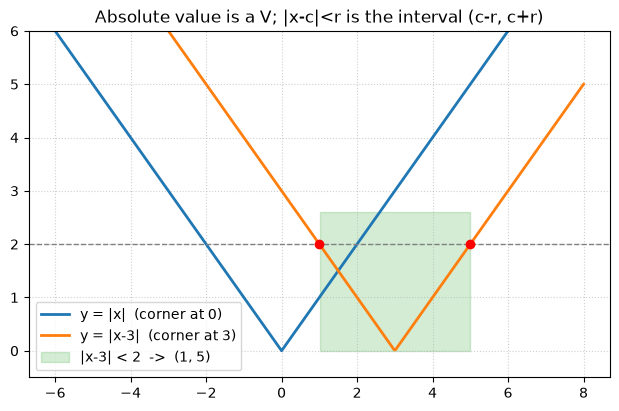

In [4]:
# The V-shape graph of y = |x|, and a shifted/scaled version y = |x-3|.
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-6, 8, 400)
plt.figure(figsize=(7.5, 4.5))
plt.plot(xs, np.abs(xs),     lw=2, label='y = |x|  (corner at 0)')
plt.plot(xs, np.abs(xs - 3), lw=2, label='y = |x-3|  (corner at 3)')
# show Example F: |x-3| < 2 is the interval (1, 5)
plt.axhline(2, color='gray', ls='--', lw=1)
plt.fill_between(xs, 0, 2.6, where=(np.abs(xs - 3) < 2), color='tab:green', alpha=0.2,
                 label='|x-3| < 2  ->  (1, 5)')
plt.scatter([1, 5], [2, 2], color='red', zorder=5)
plt.ylim(-0.5, 6); plt.legend(); plt.grid(True, ls=':', alpha=0.6)
plt.title('Absolute value is a V; |x-c|<r is the interval (c-r, c+r)')
plt.show()

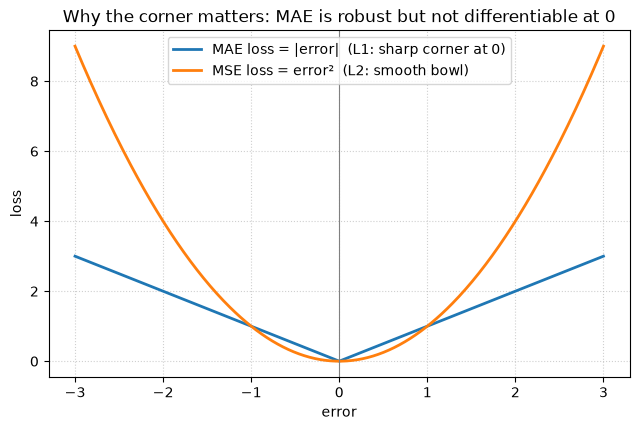

In [5]:
# AI HOOK: |x| is the 1-D L1 error. Compare MAE (|error|) with MSE (error^2).
import numpy as np
import matplotlib.pyplot as plt

err = np.linspace(-3, 3, 400)          # the error = prediction - truth
mae = np.abs(err)                      # mean-absolute-error shape: a V (L1)
mse = err**2                           # mean-squared-error shape: a parabola (L2)

plt.figure(figsize=(7.5, 4.5))
plt.plot(err, mae, lw=2, label='MAE loss = |error|  (L1: sharp corner at 0)')
plt.plot(err, mse, lw=2, label='MSE loss = error²  (L2: smooth bowl)')
plt.axvline(0, color='gray', lw=0.8)
plt.legend(); plt.grid(True, ls=':', alpha=0.6)
plt.xlabel('error'); plt.ylabel('loss')
plt.title('Why the corner matters: MAE is robust but not differentiable at 0')
plt.show()

# The corner at 0 (where |x| is not differentiable) is the SAME kind of corner as ReLU;
# AI handles it with a "subgradient". MSE punishes big errors more (squares them);
# MAE treats all errors in proportion, so it is more robust to outliers.

## 5. Exercises (fill in the cells yourself)

Solve by hand (isolate the absolute value first!), give inequalities in **interval
notation**, and check with `sympy`. Use the **distance** picture whenever it is faster.
Easy $\to$ hard; last few are proofs.

**Equations**
1. $|x| = 9$.
2. $|x - 4| = 6$.
3. $|3x + 2| = 10$.
4. $|5 - 2x| = 0$  (how many solutions?).
5. $|x + 1| = -4$.
6. $|2x - 7| = |x + 1|$.

**Inequalities (give interval notation)**
7. $|x| \le 5$.
8. $|x - 3| < 4$.
9. $|2x + 1| \ge 7$.
10. $|4 - x| > 2$.
11. $3|x - 2| - 5 \le 4$  (isolate first).
12. $|5x + 3| < -2$  (think before you compute).
13. $-2\,|x + 1| \ge -8$  (careful: dividing by $-2$ flips — topic 13).

**Distance / modelling**
14. Write as an absolute-value inequality: "$x$ is within $0.01$ of $2$." Then solve it.
15. A machine part must be $50\,$mm long with tolerance $0.3\,$mm. Write $|L - 50|\le0.3$ as
    an interval for the allowed length $L$.

**Harder / proofs**
16. Solve $|2x - 1| \le |x + 3|$ by **squaring both sides** (both sides $\ge0$), then a sign
    chart. Compare with the distance reading.
17. Solve $|x - 1| + |x + 2| = 5$ by splitting into cases on the sign of each inside part
    (three regions: $x<-2$, $-2\le x<1$, $x\ge1$).
18. **Prove** $|xy| = |x|\,|y|$ for all real $x,y$ using $|t|=\sqrt{t^2}$.
19. **Prove** the triangle inequality $|x+y|\le|x|+|y|$ from $-|x|\le x\le|x|$ (Theorem 4),
    and give an example where equality holds and one where it is strict.
20. **Prove** the reverse triangle inequality $\big||x|-|y|\big|\le|x-y|$, and use it to
    explain why "small change in input $\Rightarrow$ small change in $|x|$" (a stability /
    continuity statement).

In [6]:
# Exercise 1 — your work here


In [7]:
# Exercise 2 — your work here


In [8]:
# Exercise 3 — your work here


In [9]:
# Exercise 4 — your work here


In [10]:
# Exercise 5 — your work here


In [11]:
# Exercise 6 — your work here


In [12]:
# Exercise 7 — your work here


In [13]:
# Exercise 8 — your work here


In [14]:
# Exercise 9 — your work here


In [15]:
# Exercise 10 — your work here


In [16]:
# Exercise 11 — your work here


In [17]:
# Exercise 12 — your work here


In [18]:
# Exercise 13 — your work here


In [19]:
# Exercise 14 — your work here


In [20]:
# Exercise 15 — your work here


In [21]:
# Exercise 16 — your work here


In [22]:
# Exercise 17 — your work here


In [23]:
# Exercise 18 — your work here


In [24]:
# Exercise 19 — your work here


In [25]:
# Exercise 20 — your work here


## 6. `uv` note — how to run this notebook

Managed with **`uv`**. From the project root (`C:\dev\math`):

- `uv sync` — install dependencies (`numpy`, `sympy`, `matplotlib`, `jupyterlab`).
- `uv run jupyter lab` — open `notebooks/14-absolute-value-equations-inequalities.ipynb`.
- Re-run everything from the terminal (self-test):
  `uv run jupyter nbconvert --to notebook --execute notebooks/14-absolute-value-equations-inequalities.ipynb`.

Restart the kernel and **Run All** to repeat the tutorial. **The habits to keep:** isolate
the absolute value first; read $|x-c|$ as *distance*; $|x|<a$ is one interval, $|x|>a$ is two
rays; and never forget $\sqrt{x^2}=|x|$, not $x$.